# AdaBoost Ensemble Regressor Predictions

AdaBoost (Adaptive Boosting) is an ensemble technique that trains sequential weak learners (typically shallow trees), weighting subsequent models to emphasize reconstruction errors of prior runs. This notebook generates a noisy sine wave curve, fits an AdaBoost regressor containing 50 shallow decision trees, and visualizes how boosting resolves noisy non-linear functions compared to a single weak learner.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Generate synthetic non-linear dataset (sine wave + noise)
np.random.seed(66)
n_samples = 300

X_data = np.sort(5 * np.random.rand(n_samples, 1), axis=0)
y_data = np.sin(X_data).ravel() + np.random.normal(0, 0.15, n_samples)

df = pd.DataFrame(X_data, columns=['X_Feature'])
df['Y_Target'] = y_data
df.head(10)



,X_Feature,Y_Target
0,0.002567,-0.101519
1,0.064571,0.185746
2,0.074104,-0.311461
3,0.086984,0.060053
4,0.111279,0.165941
5,0.111906,0.019588
6,0.133213,0.221135
7,0.146105,-0.059802
8,0.156593,0.023576
9,0.156729,0.258585


## Models Fitting & Evaluations

We split the data into 80% train and 20% test partitions. We compare a single shallow Decision Tree (max_depth=3) against an AdaBoost ensemble using 50 estimators.



In [2]:
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42)

# Single base learner
dt_model = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)

# AdaBoost ensemble model
ada_model = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=3),
    n_estimators=50,
    learning_rate=0.1,
    random_state=42
)
ada_model.fit(X_train, y_train)

# Evaluate metrics
y_pred_dt = dt_model.predict(X_test)
y_pred_ada = ada_model.predict(X_test)

r2_dt = r2_score(y_test, y_pred_dt)
r2_ada = r2_score(y_test, y_pred_ada)

mse_dt = mean_squared_error(y_test, y_pred_dt)
mse_ada = mean_squared_error(y_test, y_pred_ada)

print("Single Tree Regressor:")
print(f"R² Score: {r2_dt:.4f} | MSE: {mse_dt:.4f}")
print("\nAdaBoost Regressor:")
print(f"R² Score: {r2_ada:.4f} | MSE: {mse_ada:.4f}")



Single Tree Regressor:
R² Score: 0.9120 | MSE: 0.0502

AdaBoost Regressor:
R² Score: 0.9338 | MSE: 0.0378


## Predictions Curve Comparison

We plot the training data points alongside the regression curves of both models over a dense grid to observe the step-like predictions.



<cell>:22: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



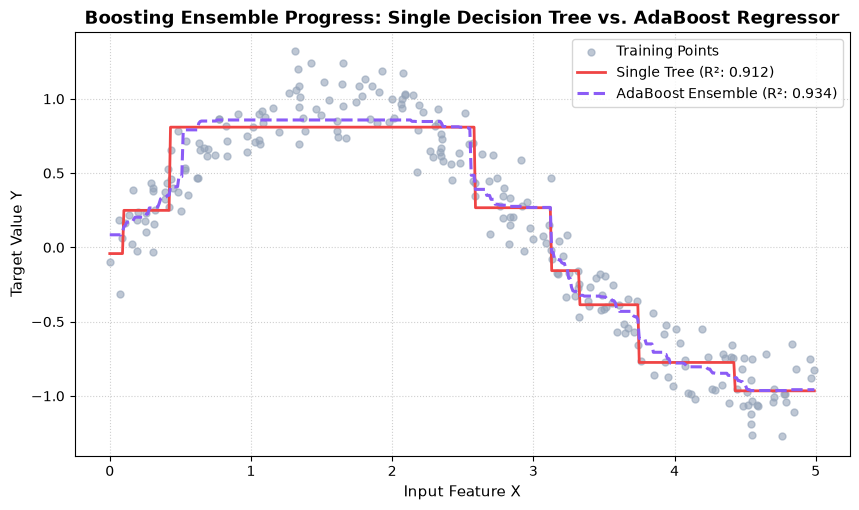

In [3]:
# Dense input grid for plotting curves
X_grid = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]
y_grid_dt = dt_model.predict(X_grid)
y_grid_ada = ada_model.predict(X_grid)

plt.figure(figsize=(10, 5.5))

# Plot scatter train points
plt.scatter(X_train, y_train, color='#94A3B8', alpha=0.6, label='Training Points', s=25)

# Plot single tree curve
plt.plot(X_grid, y_grid_dt, color='#EF4444', label=f'Single Tree (R²: {r2_dt:.3f})', linewidth=2)

# Plot AdaBoost ensemble curve
plt.plot(X_grid, y_grid_ada, color='#8B5CF6', label=f'AdaBoost Ensemble (R²: {r2_ada:.3f})', linewidth=2.2, linestyle='--')

plt.title('Boosting Ensemble Progress: Single Decision Tree vs. AdaBoost Regressor', fontsize=13, fontweight='bold')
plt.xlabel('Input Feature X', fontsize=11)
plt.ylabel('Target Value Y', fontsize=11)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
